# Netflix Movies and TV Shows 🍿🎥✮⋆˙

## Required Libraries

In [134]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 
import re

## Read the Dataset

In [135]:
df = pd.read_csv('netflix_titles.csv')

# Now let's do some basic checks ✅

In [136]:
df.shape

(8807, 12)

In [137]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploratory Data Analysis (EDA)

### Information

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Description

In [139]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [140]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Value Analysis 

In [141]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Missing Value Percentage

In [142]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64

## Handling Missing Values

# For categorical columns we will fill it with 'unknown'

# And for Numeric columns we will fill it with mode

In [144]:
cols = ['director', 'cast', 'country']

for col in cols:
    df[col] = df[col].fillna('Unknown')
    

cols = ['date_added', 'rating', 'duration']
for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Now we have 0 missing values

In [145]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Checking if our data has Duplicates

In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

#### Now Let's remove unnecessary columns.

In [148]:
df.drop(columns=['show_id'], axis=1, inplace=True)

#### Date Column has an different dtype

In [149]:
df['date_added'].dtype

dtype('O')

# Let's fix it 

In [150]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')

## Rating columns has some outliers, let's remove them.

In [151]:
df['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [152]:
df = df[~df['rating'].str.contains('min', na=False)]

#### Check if we have outlier values

In [153]:
df['release_year'].min()

np.int64(1925)

In [154]:
df['release_year'].max()

np.int64(2021)

In [155]:
df['date_added'].dt.year.min()
df['date_added'].dt.year.max()

np.int32(2021)

### Now let's move on to Uni Analysis

In [156]:
counts = df['type'].value_counts()
labels = counts.index  
values = counts.values

## Now let's plot it and check distribution of the types.

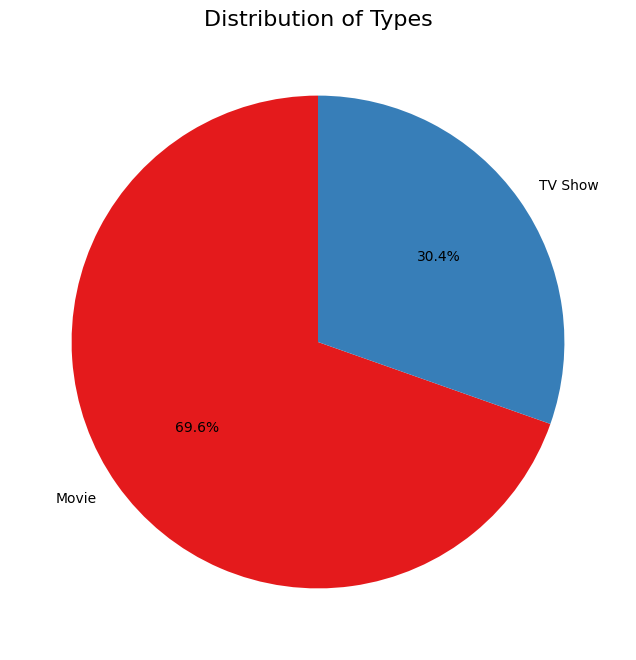

In [157]:
plt.figure(figsize=(8,8))
plt.pie(
    values,
    labels=labels,
    colors=sns.color_palette("Set1", len(labels)), 
    autopct='%1.1f%%',  
    startangle=90
)
plt.title("Distribution of Types", fontsize=16)
plt.show()

In [158]:
df['country'].value_counts()

country
United States                                             2815
India                                                      972
Unknown                                                    831
United Kingdom                                             419
Japan                                                      245
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64

## Distribution of Top 5 countries and More

In [159]:
counts = df['country'].value_counts()
top_5 = counts.head(5)
others = pd.Series([counts[5:].sum()], index=['Others'])
plot_data = pd.concat([top_5, others])

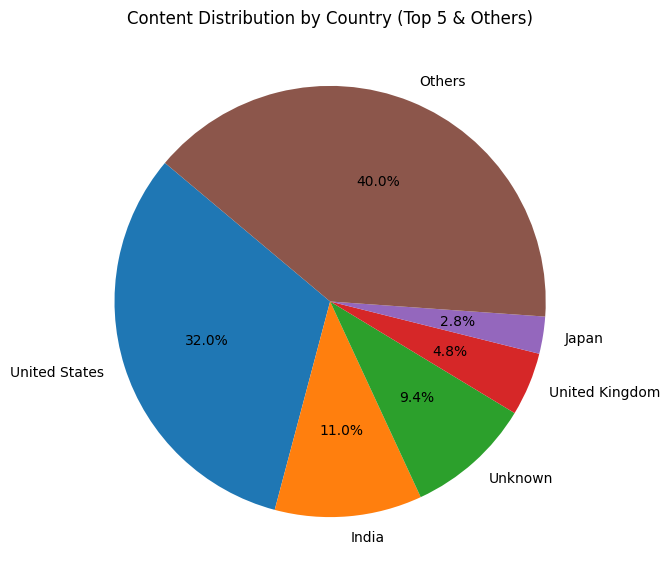

In [160]:
plt.figure(figsize=(10, 7))
plt.pie(
    plot_data.values, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
)
plt.title('Content Distribution by Country (Top 5 & Others)')
plt.show()

**Understanding – Movies Added Over Time**

Both Movies and TV Shows grow strongly from the mid‑2010-11 onwards, reflecting Netflix’s rapid expansion during the streaming boom

#### Distribution of Movie Durations

In [161]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

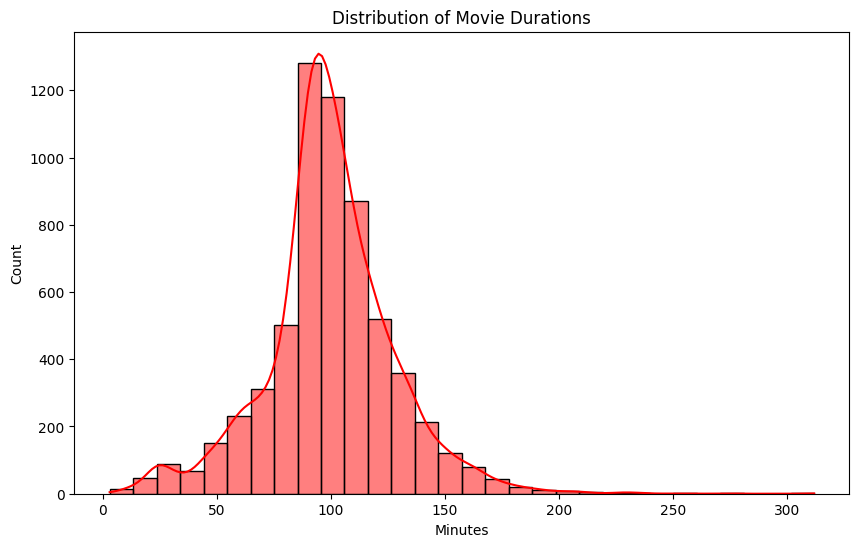

In [162]:
plt.figure(figsize=(10, 6))
sns.histplot(movies_df['duration_min'], bins=30, kde=True, color='red')
plt.title('Distribution of Movie Durations')
plt.xlabel('Minutes')
plt.show()

**Understanding - Movie Duration Analysis**
Netflix adheres to standard Hollywood cinema standards for movie lengths, showing little inclination towards very long (over 3 hours) or very short films, ensuring a comfortable viewing experience for users.

#### Let's Plot Top 15 Genre (action or drama or romance)

C:\Users\Yash\AppData\Local\Temp\ipykernel_25912\1559803357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=genres, order=genres.value_counts().index[:15], palette='rocket')


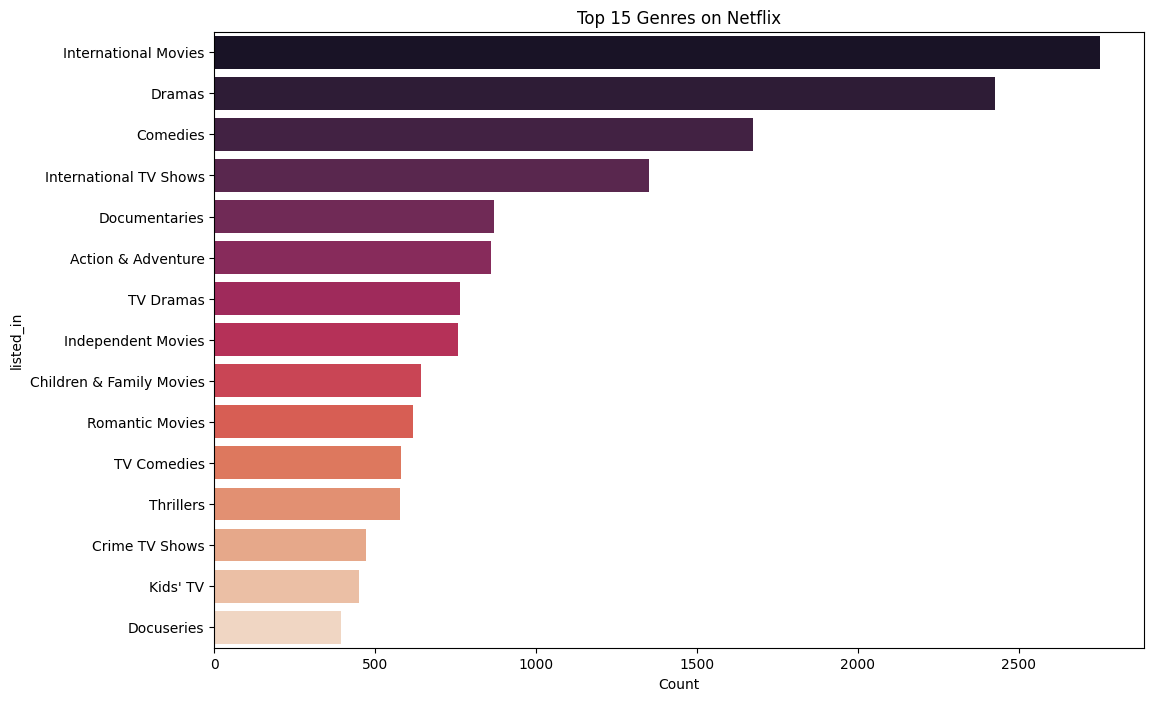

In [163]:
genres = df['listed_in'].str.split(', ').explode().reset_index(drop=True)

plt.figure(figsize=(12, 8))
sns.countplot(y=genres, order=genres.value_counts().index[:15], palette='rocket')
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.show()

**Understanding - Analysis of the Top 15 Genres**

International Movies, Dramas, and Comedies top the list as the most frequently appearing genres.

In [164]:
df['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

## Let's plot count of each rating 

C:\Users\Yash\AppData\Local\Temp\ipykernel_25912\3995475898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='magma')


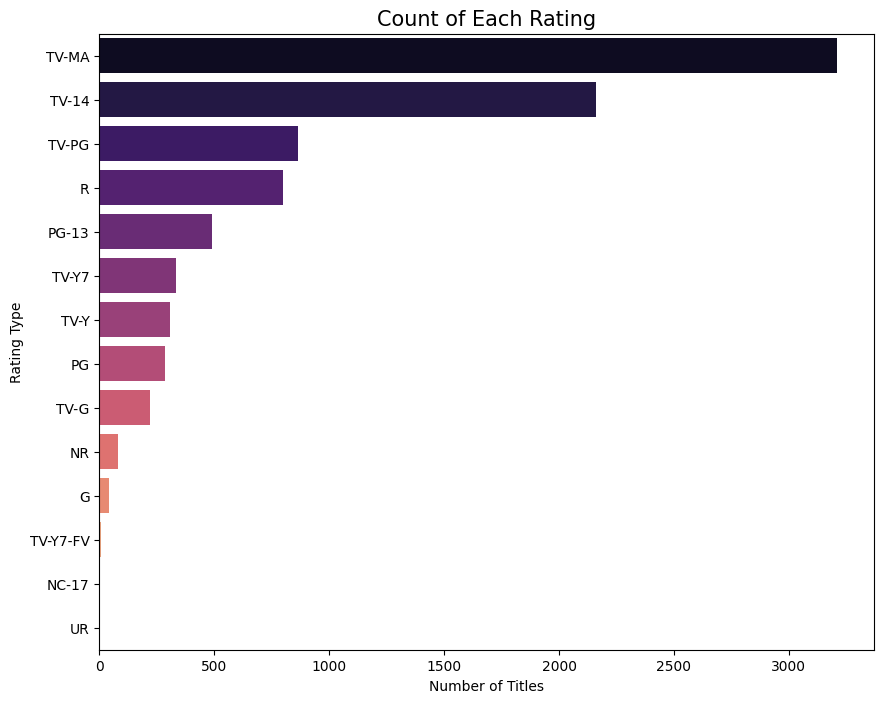

In [165]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='magma')

plt.title('Count of Each Rating', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Rating Type')
plt.show()

**Understanding – Rating Distribution**

A few maturity ratings dominate (such as TV-MA and TV-14), indicating that Netflix focuses heavily on teen and adult audiences rather than purely children-only content.

### Uni Analysis is done 

# Now we will focus on Bivariate Analysis

#### Distribution of Type with date_added

In [166]:
df['year_added'] = pd.to_datetime(df['date_added']).dt.year

In [167]:
data = (
    df.groupby(['type', 'year_added'])
      .size()
      .reset_index(name="count")
)

data

,type,year_added,count
0,Movie,2008,1
1,Movie,2009,2
2,Movie,2010,1
3,Movie,2011,13
4,Movie,2012,3
5,Movie,2013,6
6,Movie,2014,19
7,Movie,2015,56
8,Movie,2016,251
9,Movie,2017,838


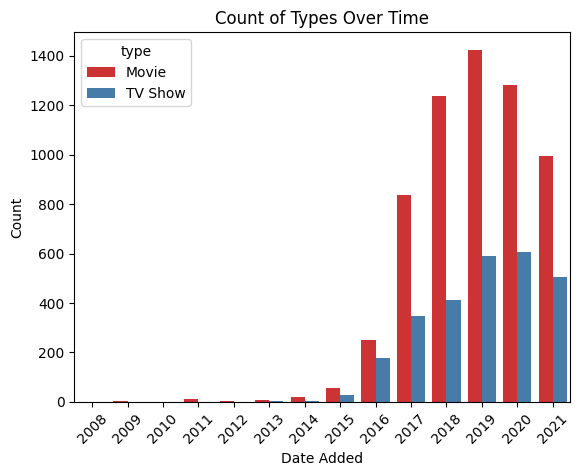

In [168]:
sns.barplot(
    data=data,
    x="year_added",
    y="count",
    hue="type",
    palette="Set1"
)

plt.xticks(rotation=45)
plt.title("Count of Types Over Time")
plt.xlabel("Date Added")
plt.ylabel("Count")
plt.show()


**Understanding – Country Concentration vs Long Tail**

The top five countries contribute a large share of all titles, but the sizeable "Others" slice confirms a long tail of many smaller content-producing countries.

#### Distribution of Type with release_year

In [169]:
data = (
    df.groupby(['type', 'release_year'])
      .size()
      .reset_index(name="count")
)

data

,type,release_year,count
0,Movie,1942,2
1,Movie,1943,3
2,Movie,1944,3
3,Movie,1945,3
4,Movie,1946,1
...,...,...,...
114,TV Show,2017,265
115,TV Show,2018,380
116,TV Show,2019,397
117,TV Show,2020,436


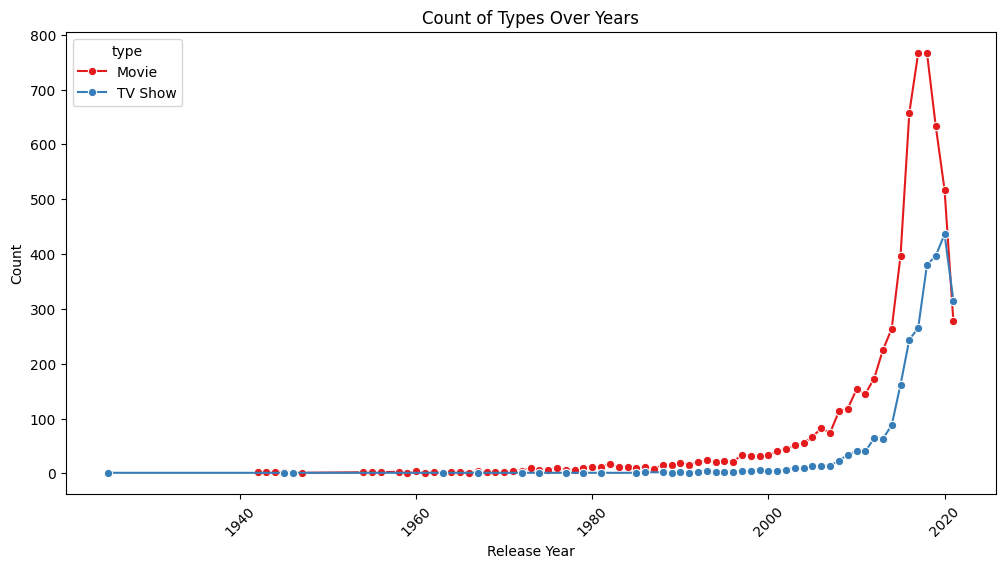

In [170]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=data,
    x="release_year",
    y="count",
    hue="type",
    marker="o",
    palette="Set1"
)
plt.title("Count of Types Over Years")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


**Understanding – Top Content Countries**

A small group of countries, led by the United States with strong contributions from India, the UK and others, produces most of the catalog, showing that Netflix’s library is concentrated in a few key markets.

#### Distribution of Type with Country

In [171]:
data = (
    df.groupby(['type', 'country'])
      .size()
      .reset_index(name="count").sort_values(by=['count'], ascending=False)
)

data

,type,country,count
525,Movie,United States,2055
218,Movie,India,893
812,TV Show,United States,760
640,Movie,Unknown,440
847,TV Show,Unknown,391
...,...,...,...
7,Movie,"Argentina, Italy",1
6,Movie,"Argentina, France, United States, Germany, Qatar",1
5,Movie,"Argentina, France",1
4,Movie,"Argentina, Chile, Peru",1


In [172]:
data.head()

,type,country,count
525,Movie,United States,2055
218,Movie,India,893
812,TV Show,United States,760
640,Movie,Unknown,440
847,TV Show,Unknown,391


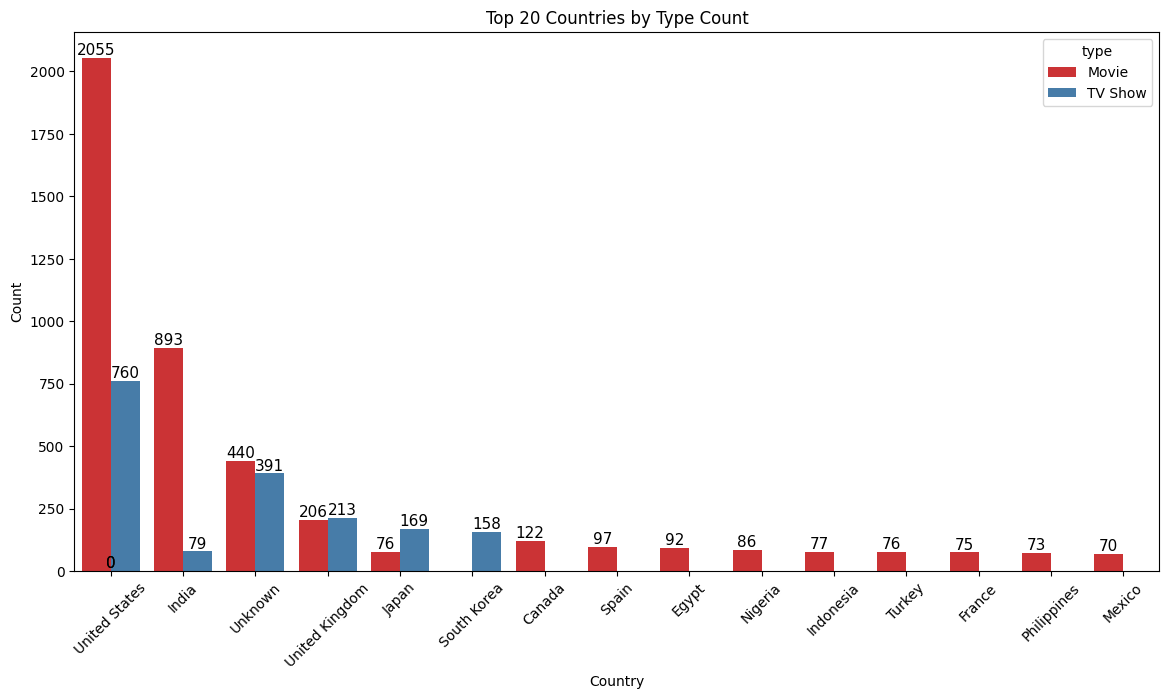

In [173]:
plt.figure(figsize=(14,7)) 
ax = sns.barplot(
    data=data.head(20),
    x="country",
    y="count",
    hue="type",
    palette="Set1",  
    dodge=True      
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        color="black"
    )
    
plt.title("Top 20 Countries by Type Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


**Understanding – Content Types Distribution**

Movies clearly dominate the catalog, while TV Shows form a smaller but still meaningful portion of the available content.

#### Average Movie Duration Over the Years

In [174]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

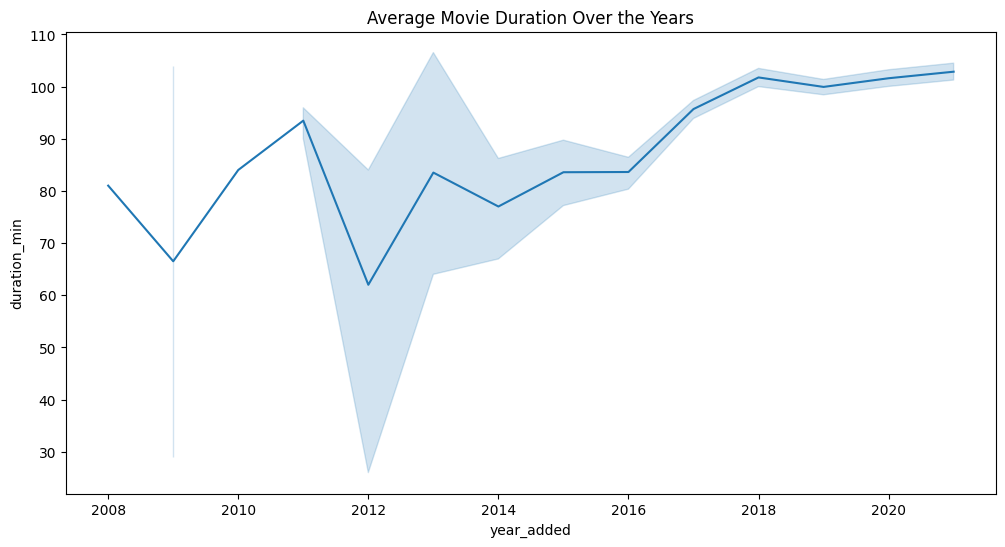

In [175]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=movies_df, x='year_added', y='duration_min')
plt.title('Average Movie Duration Over the Years')
plt.show()

#### Rating Distribution: Movie vs TV Show

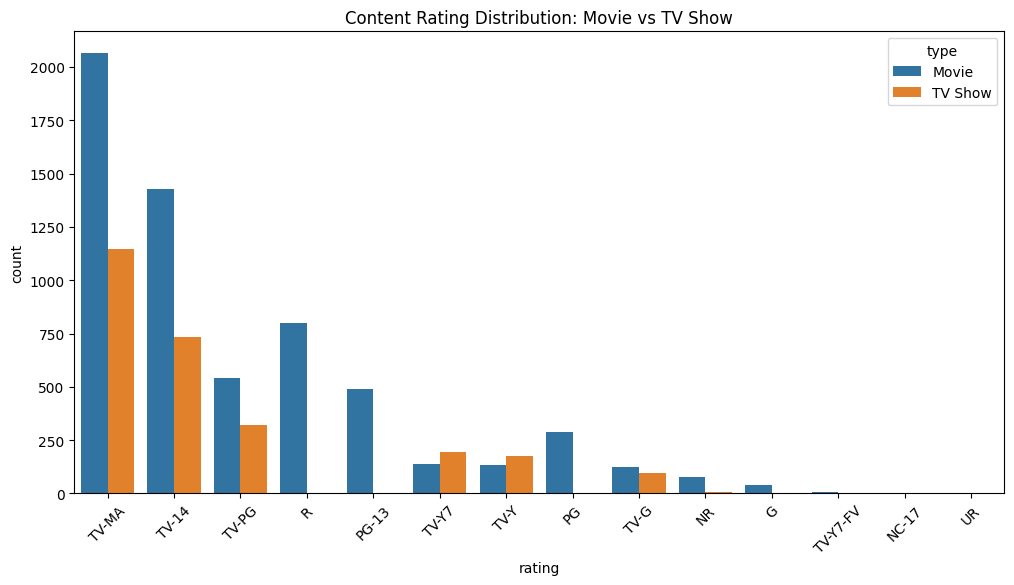

In [176]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index)
plt.title('Content Rating Distribution: Movie vs TV Show')
plt.xticks(rotation=45)
plt.show()

## Thank You for your time! 💘
        - 9keg2 (Yash)

If you liked it consider following me on -

linkedin - https://www.linkedin.com/in/yash-jaiswal-b024b9345/

github - https://github.com/9keg2

youtube - https://www.youtube.com/@foriinyash